# Resource sizing sandbox — run 599278

Goal: pick per-task-type memory + runtime asks from the last run's actuals.

The lesson we hit: `LinearModel(n_scams, n_smooths)` on **raw counts** floods the
light tasks — a single plane through a 50x cost range has an intercept that sits
far above `lm`. The fix is *features*, not a different tool: encode the **tier**,
and the same linear model just recovers each tier's mean. Safety then has to be
per-tier too (idd-tools' policy adds the *global* worst residual to every task).

In [1]:
import logging; logging.disable(logging.INFO)   # silence jobmon debug spew
from pathlib import Path
import numpy as np, pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 60)

WID = 599278
CACHE = Path(f"/ihme/homes/bcreiner/resource_sizing/wf{WID}_tasks.parquet")
if CACHE.exists():
    df = pd.read_parquet(CACHE)                      # instant (pre-seeded)
else:                                                # regenerate for a future run:
    from idd_tools.jobmon.jobmon_query import collect_workflow
    df = collect_workflow(WID, include_sacct=False, chunk_size=200)  # chunk<200 avoids the GET-400
    CACHE.parent.mkdir(parents=True, exist_ok=True); df.to_parquet(CACHE)

# features: n_smooths / n_scams live in the jobmon task name  (...-<window>_n{smooths}_s{scams}_bin{k})
name = df["task_name"].astype(str)
df["n_smooths"] = pd.to_numeric(name.str.extract(r"_n(\d+)_")[0],   errors="coerce")
df["n_scams"]   = pd.to_numeric(name.str.extract(r"_s(\d+)_bin")[0], errors="coerce")
df["mem_g"]     = pd.to_numeric(df["jobmon_mem_gib"],    errors="coerce")   # jobmon MaxRSS (GiB)
df["rt_s"]      = pd.to_numeric(df["jobmon_runtime_s"],  errors="coerce")   # elapsed (s)
df["template"]  = df["template"].str.replace("_task_id", "", regex=False)
df = df.dropna(subset=["n_smooths","n_scams","mem_g","rt_s"]).copy()

# engine-aware tier: scam by n_scams; the n_scams==0 world split into lm vs gam by n_smooths
def tier(r):
    if r.n_scams > 0:  return f"scam_s{int(r.n_scams)}"
    return "lm" if r.n_smooths == 0 else f"gam_n{int(r.n_smooths)}"
df["tier"] = df.apply(tier, axis=1)

print(f"{len(df)} tasks")
df.groupby(["template","tier"]).agg(n=("mem_g","size"),
    mem_med=("mem_g","median"), mem_max=("mem_g","max"),
    rt_med=("rt_s","median"),  rt_max=("rt_s","max")).round(1)

5826 tasks


n  mem_med  mem_max  rt_med  rt_max
template     tier                                           
is_cell      gam_n1      8      2.3      2.5   187.0     223
             lm         12      1.1      1.2    20.0      28
             scam_s1    80      3.3      3.9   313.5     592
             scam_s2   130      3.5      4.0   401.0     795
             scam_s3   110      3.8      4.6   473.5    1322
             scam_s4    52      4.1      4.6   524.0     837
             scam_s5    13      4.3      4.5   602.0    1096
             scam_s6     1      4.0      4.0   497.0     497
oos_temporal gam_n1    110      1.8      2.4    84.0     234
             lm        160      1.0      1.3    15.0      21
             scam_s1  1070      2.3      3.5   136.0     404
             scam_s2  1740      2.5      3.7   168.0     513
             scam_s3  1470      2.6      3.9   195.0     696
             scam_s4   690      2.7      4.2   219.0     770
             scam_s5   170      2.8      4.1   239.5     665
             scam_s6    10      3.0      4.1   259.0     445

## Model A — raw counts (the broken one)

`target ~ n_scams + n_smooths`. Watch the **intercept**: it's the model's floor
prediction, and it's an order of magnitude above the `lm` tasks' real cost.

In [ ]:
def fit_ols(X, y, intercept=True):
    X = np.asarray(X, float)
    A = np.column_stack([np.ones(len(X)), X]) if intercept else X
    beta, *_ = np.linalg.lstsq(A, np.asarray(y, float), rcond=None)
    return beta


rt_s :  201.45 +  35.75*n_scams +  52.90*n_smooths   |  lm prediction @(0,0) = 201.4s   vs lm ACTUAL median = 20.0s
mem_g:    2.63 +   0.18*n_scams +   0.19*n_smooths   |  lm prediction @(0,0) = 2.6G   vs lm ACTUAL median = 1.1G


/tmp/ipykernel_3951418/1672568510.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['n_prod'] = d.n_scams * d.n_smooths


log rt_s :   4.35 +  0.55*n_scams +  0.55*n_smooths   |  lm pred @(0,0) = exp(4.35) = 77.1s   vs lm ACTUAL median = 20.0s
log mem_g:   0.63 +  0.22*n_scams +  0.20*n_smooths   |  lm pred @(0,0) = exp(0.63) = 1.9G   vs lm ACTUAL median = 1.1G


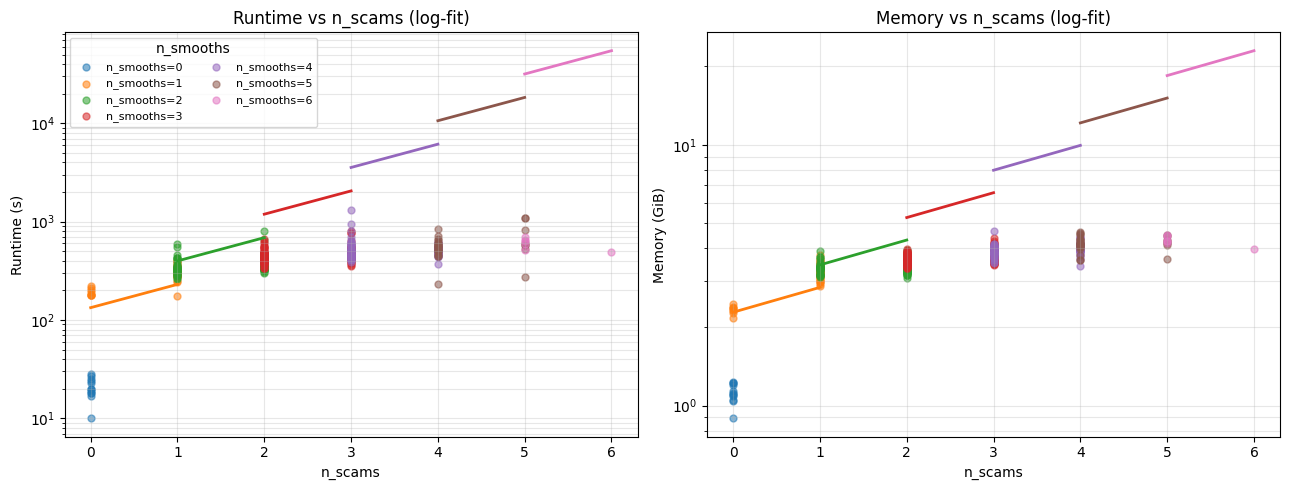

In [10]:
# 1x2 panel, fits in LOG space: log(target) ~ n_scams + n_smooths
import matplotlib.pyplot as plt

d = df[df.template == "is_cell"]
d['n_prod'] = d.n_scams * d.n_smooths

for tgt, unit in [("rt_s", "s"), ("mem_g", "G")]:
    b = fit_ols(d[["n_scams", "n_smooths", "n_prod"]], np.log(d[tgt]))          # fit on log(target)
    lm_actual = d[(d.n_scams == 0) & (d.n_smooths == 0)][tgt].median()
    print(f"log {tgt:5s}: {b[0]:6.2f} + {b[1]:5.2f}*n_scams + {b[2]:5.2f}*n_smooths"
          f"   |  lm pred @(0,0) = exp({b[0]:.2f}) = {np.exp(b[0]):.1f}{unit}"
          f"   vs lm ACTUAL median = {lm_actual:.1f}{unit}")




b_rt  = fit_ols(d[["n_scams", "n_smooths", "n_prod"]], np.log(d["rt_s"]))
b_mem = fit_ols(d[["n_scams", "n_smooths", "n_prod"]], np.log(d["mem_g"]))

smooth_vals = sorted(d["n_smooths"].unique())
cmap   = plt.get_cmap("tab10")
colors = {v: cmap(i % 10) for i, v in enumerate(smooth_vals)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
panels = [("rt_s",  b_rt,  "Runtime (s)",  "Runtime vs n_scams (log-fit)"),
          ("mem_g", b_mem, "Memory (GiB)", "Memory vs n_scams (log-fit)")]
for ax, (tgt, beta, ylab, title) in zip(axes, panels):
    for v in smooth_vals:
        sub = d[d["n_smooths"] == v]
        ax.scatter(sub["n_scams"], sub[tgt], alpha=0.55, s=25,
                   color=colors[v], label=f"n_smooths={int(v)}")
        xr = np.arange(sub["n_scams"].min(), sub["n_scams"].max() + 1)
        if len(xr) > 1:
            ax.plot(xr, np.exp(beta[0] + beta[1] * xr + beta[2] * v), color=colors[v], lw=2)  # exp back to real units
    ax.set_yscale("log")
    ax.set_xlabel("n_scams"); ax.set_ylabel(ylab); ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend(title="n_smooths", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


In [11]:
# log(target) ~ n_scams + n_smooths + I(n_scams==0) + I(n_scams==0):n_smooths
def design(dd):
    ns  = dd["n_scams"].to_numpy(float)
    nsm = dd["n_smooths"].to_numpy(float)
    z0  = (ns == 0).astype(float)                     # factor: the n_scams==0 (lm/gam) regime
    return np.column_stack([ns, nsm, z0, z0 * nsm])   # fit_ols prepends the intercept
COEF = ["intercept", "n_scams", "n_smooths", "z0", "z0:n_smooths"]

def predict_ols(X, beta):                             # design (no intercept col) + beta with one
    return np.column_stack([np.ones(len(X)), np.asarray(X, float)]) @ beta

d = df[df.template == "is_cell"]
for tgt, unit in [("rt_s", "s"), ("mem_g", "G")]:
    b = fit_ols(design(d), np.log(d[tgt]))
    print(f"\nlog {tgt}:  " + "  ".join(f"{c}={v:.3f}" for c, v in zip(COEF, b)))
    for ns, nsm, nm in [(0, 0, "lm"), (0, 1, "gam"), (3, 3, "scam_s3"), (5, 6, "scam_s5")]:
        z0   = 1.0 if ns == 0 else 0.0
        pred = np.exp(b[0] + b[1]*ns + b[2]*nsm + b[3]*z0 + b[4]*z0*nsm)
        act  = d[(d.n_scams == ns) & (d.n_smooths == nsm)][tgt].median()
        print(f"   {nm:8s} pred={pred:7.1f}{unit}   actual_med={act:7.1f}{unit}")



log rt_s:  intercept=5.626  n_scams=0.063  n_smooths=0.101  z0=-2.625  z0:n_smooths=2.158
   lm       pred=   20.1s   actual_med=   20.0s
   gam      pred=  192.5s   actual_med=  187.0s
   scam_s3  pred=  453.3s   actual_med=  462.0s
   scam_s5  pred=  695.2s   actual_med=  631.0s

log mem_g:  intercept=1.115  n_scams=0.030  n_smooths=0.038  z0=-1.009  z0:n_smooths=0.702
   lm       pred=    1.1G   actual_med=    1.1G
   gam      pred=    2.3G   actual_med=    2.3G
   scam_s3  pred=    3.7G   actual_med=    3.7G
   scam_s5  pred=    4.4G   actual_med=    4.3G


In [12]:
# residuals are log(actual/pred); in log space a global safety quantile is a PROPORTIONAL margin (no flooding)
def log_fit_ask(d, tgt, safety_q=0.95, floor=1.0, mult=1.0):
    X = design(d); y = np.log(d[tgt].to_numpy(float))
    b = fit_ols(X, y)
    pred_log = predict_ols(X, b)
    resid    = y - pred_log                            # = log(actual / pred)
    q        = np.quantile(resid, safety_q)            # constant in log space -> multiplies every pred equally
    ask      = np.maximum(np.exp(pred_log + q) * mult, floor)
    return pd.DataFrame({"tier": d["tier"].values, "pred": np.exp(pred_log), "resid": resid, "ask": ask})

for tmpl in ["is_cell", "oos_temporal"]:
    d = df[df.template == tmpl]
    rt  = log_fit_ask(d, "rt_s",  floor=300.0, mult=1.0)   # runtime: 5-min floor, no cgroup mult
    mem = log_fit_ask(d, "mem_g", floor=1.0,   mult=2.0)   # memory: 2x-MaxRSS floor as a x2 multiplier
    summ = pd.DataFrame({
        "n":        rt.groupby("tier")["pred"].size(),
        "rt_pred":  rt.groupby("tier")["pred"].median().round(0),
        "rt_ask_m": (rt.groupby("tier")["ask"].max() / 60).round(1),
        "resid_sd": rt.groupby("tier")["resid"].std().round(2),   # ~constant across tiers => log is the right scale
        "mem_pred": mem.groupby("tier")["pred"].median().round(2),
        "mem_askG": mem.groupby("tier")["ask"].max().round(1),
    })
    print(f"\n===== {tmpl} =====\n{summ.to_string()}")



===== is_cell =====
           n  rt_pred  rt_ask_m  resid_sd  mem_pred  mem_askG
tier                                                         
gam_n1     8    193.0       5.0      0.08      2.33       5.1
lm        12     20.0       5.0      0.28      1.11       2.4
scam_s1   80    327.0       8.0      0.16      3.26       7.4
scam_s2  130    385.0       9.5      0.16      3.49       8.0
scam_s3  110    453.0      11.2      0.19      3.74       8.5
scam_s4   52    534.0      13.1      0.18      4.00       9.1
scam_s5   13    629.0      15.5      0.36      4.28       9.8
scam_s6    1    740.0      16.5       NaN      4.58      10.1

===== oos_temporal =====
            n  rt_pred  rt_ask_m  resid_sd  mem_pred  mem_askG
tier                                                          
gam_n1    110     74.0       5.0      0.45      1.72       4.5
lm        160     15.0       5.0      0.24      0.97       2.6
scam_s1  1070    133.0       5.0      0.31      2.22       6.1
scam_s2  1740    1

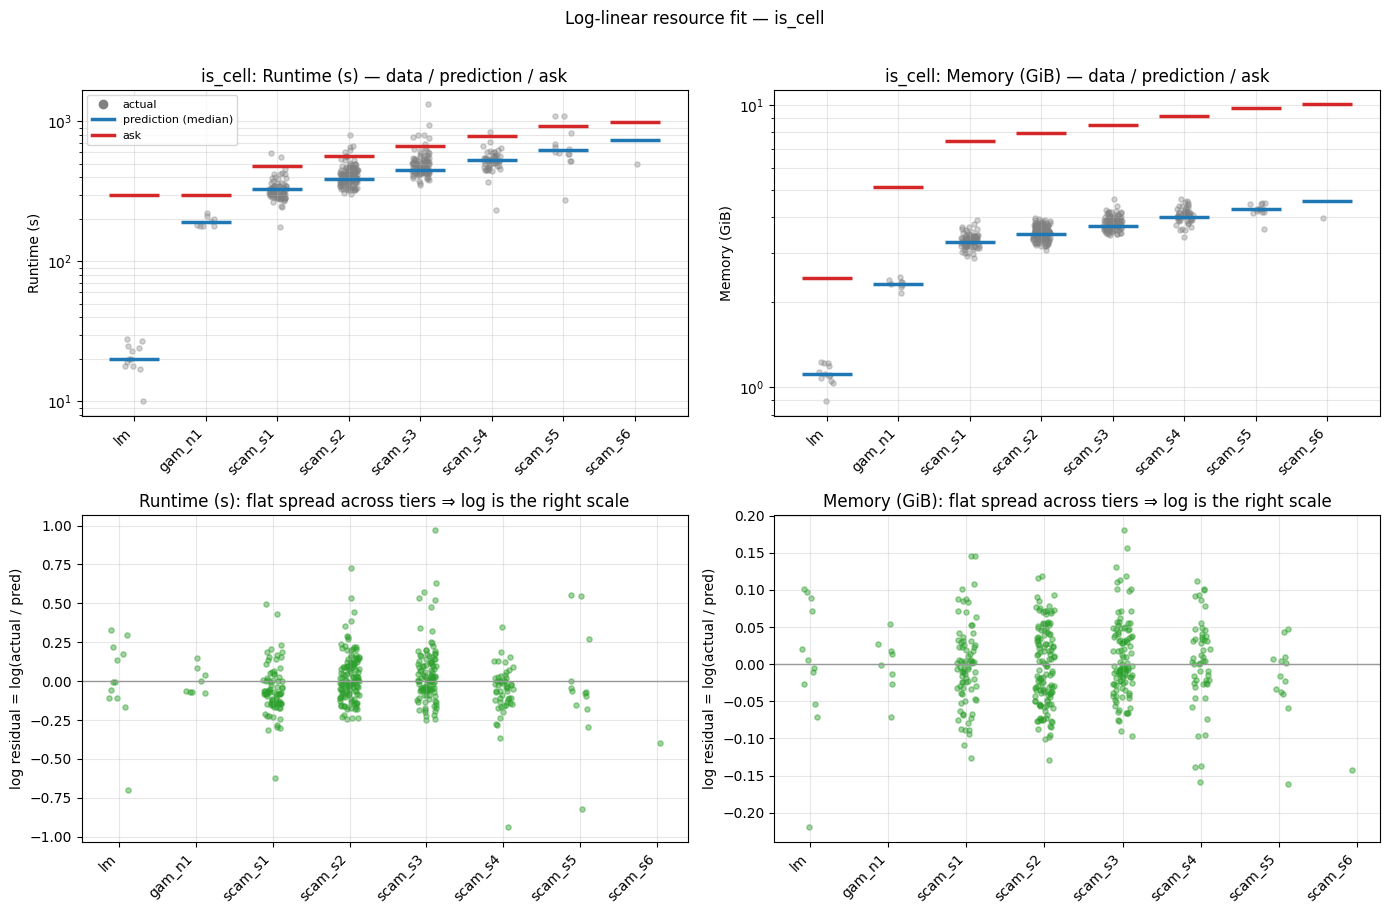

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _order(tiers):
    k = lambda t: 0 if t == "lm" else 1 if t.startswith("gam") else 10 + int(t.split("s")[-1])
    return sorted(tiers, key=k)

def plot_results(tmpl):
    d = df[df.template == tmpl]
    tiers = _order(d["tier"].unique()); xpos = {t: i for i, t in enumerate(tiers)}
    rng = np.random.default_rng(0)
    specs = [("rt_s", "Runtime (s)", 300.0, 1.0), ("mem_g", "Memory (GiB)", 1.0, 2.0)]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for col, (tgt, ylab, floor, mult) in enumerate(specs):
        res = log_fit_ask(d, tgt, floor=floor, mult=mult)          # tier, pred, resid, ask (row-aligned to d)
        x   = res["tier"].map(xpos).to_numpy() + (rng.random(len(res)) - 0.5) * 0.25
        g   = res.groupby("tier")
        # top row: actual points + per-tier prediction (blue) + ask (red)
        ax = axes[0, col]
        ax.scatter(x, d[tgt].to_numpy(), s=14, alpha=0.35, color="0.5")
        for t in tiers:
            xi, gt = xpos[t], g.get_group(t)
            ax.hlines(gt["pred"].median(), xi - 0.35, xi + 0.35, color="tab:blue", lw=2.5)
            ax.hlines(gt["ask"].max(),     xi - 0.35, xi + 0.35, color="tab:red",  lw=2.5)
        ax.set_yscale("log"); ax.set_ylabel(ylab)
        ax.set_title(f"{tmpl}: {ylab} — data / prediction / ask")
        ax.set_xticks(range(len(tiers))); ax.set_xticklabels(tiers, rotation=45, ha="right")
        ax.grid(True, which="both", alpha=0.3)
        # bottom row: log residuals
        axr = axes[1, col]
        axr.axhline(0, color="0.6", lw=1)
        axr.scatter(x, res["resid"].to_numpy(), s=14, alpha=0.45, color="tab:green")
        axr.set_ylabel("log residual = log(actual / pred)")
        axr.set_title(f"{ylab}: flat spread across tiers ⇒ log is the right scale")
        axr.set_xticks(range(len(tiers))); axr.set_xticklabels(tiers, rotation=45, ha="right")
        axr.grid(True, alpha=0.3)
    axes[0, 0].legend(handles=[
        Line2D([0], [0], marker="o", ls="", color="0.5", label="actual"),
        Line2D([0], [0], color="tab:blue", lw=2.5, label="prediction (median)"),
        Line2D([0], [0], color="tab:red",  lw=2.5, label="ask")], fontsize=8)
    fig.suptitle(f"Log-linear resource fit — {tmpl}", y=1.01)
    plt.tight_layout(); plt.show()

plot_results("is_cell")      # swap to "oos_temporal"


## Model B — give it good features: one-hot the tier

`target ~ C(tier)` (one dummy per tier, no shared intercept). The fitted
coefficient for each tier **equals that tier's mean** — i.e. the same linear
model, fed the tier, recovers the group means exactly. That's what "good
information" buys.

In [8]:
d = df[df.template == "is_cell"]
X = pd.get_dummies(d["tier"]).astype(float)          # complete dummy set, no intercept
for tgt in ["rt_s", "mem_g"]:
    coef = pd.Series(fit_ols(X, d[tgt], intercept=False), index=X.columns, name="onehot_coef")
    cmp  = pd.concat([coef, d.groupby("tier")[tgt].mean().rename("tier_mean")], axis=1)
    print(f"--- {tgt} ---"); print(cmp.round(1)); print()

--- rt_s ---
         onehot_coef  tier_mean
gam_n1         193.1      193.1
lm              20.8       20.8
scam_s1        327.1      327.1
scam_s2        417.7      417.7
scam_s3        504.6      504.6
scam_s4        529.9      529.9
scam_s5        667.0      667.0
scam_s6        497.0      497.0

--- mem_g ---
         onehot_coef  tier_mean
gam_n1           2.3        2.3
lm               1.1        1.1
scam_s1          3.3        3.3
scam_s2          3.5        3.5
scam_s3          3.8        3.8
scam_s4          4.1        4.1
scam_s5          4.3        4.3
scam_s6          4.0        4.0



## But safety must be per-tier too

Even with tier means, idd-tools' `AsymmetricClipPolicy` adds the **global** worst
under-residual to every task — so the slowest scam task's safety margin re-floods
`lm`. Fix: fit the `ResourcePredictor` **per tier**, so both the prediction and the
residual-based safety are local. Memory keeps `cgroup_multiplier=2.0` (the STANDARDS
2x-MaxRSS floor); runtime uses buffer only (no floor rule) + a 5-min minimum.

In [4]:
from idd_tools.jobmon.resources import (
    ResourcePredictor, LinearModel, AsymmetricClipPolicy, gib_to_jobmon, minutes_to_jobmon)

rows = []
for (tmpl, t), g in df.groupby(["template", "tier"]):
    memP = ResourcePredictor(LinearModel(), AsymmetricClipPolicy(buffer=0.25, cgroup_multiplier=2.0, floor=1.0))
    memP.fit(g, ["n_scams", "n_smooths"], "mem_g")
    rtP  = ResourcePredictor(LinearModel(), AsymmetricClipPolicy(buffer=0.30, cgroup_multiplier=1.0, floor=300.0))
    rtP.fit(g, ["n_scams", "n_smooths"], "rt_s")
    mem_ask_g = float(memP.predict(g).max())          # cover the heaviest task in the tier
    rt_ask_s  = float(rtP.predict(g).max())
    rows.append(dict(template=tmpl, tier=t, n=len(g),
        mem_max=round(g.mem_g.max(), 2), mem_ask=gib_to_jobmon(mem_ask_g),
        rt_max=int(g.rt_s.max()),        rt_ask=minutes_to_jobmon(rt_ask_s / 60)))

out = pd.DataFrame(rows)
out["_o"] = out.apply(lambda r: 0 if r.tier == "lm" else 1 if r.tier.startswith("gam")
                      else 10 + int(r.tier.split("s")[-1]), axis=1)
out.sort_values(["template", "_o"]).drop(columns="_o").reset_index(drop=True)

,template,tier,n,mem_max,mem_ask,rt_max,rt_ask
0,is_cell,lm,12,1.23,4G,28,2m
1,is_cell,gam_n1,8,2.46,7G,223,5m
2,is_cell,scam_s1,80,3.92,10G,592,13m
3,is_cell,scam_s2,130,3.97,11G,795,19m
4,is_cell,scam_s3,110,4.65,12G,1322,29m
5,is_cell,scam_s4,52,4.64,12G,837,19m
6,is_cell,scam_s5,13,4.49,12G,1096,24m
7,is_cell,scam_s6,1,3.97,10G,497,11m
8,oos_temporal,lm,160,1.26,4G,21,2m
9,oos_temporal,gam_n1,110,2.40,7G,234,6m


**Knobs to play with:** `buffer`, `cgroup_multiplier` (memory 2x floor — lower it
if you trust that jobmon MaxRSS already reflects the cgroup peak), the runtime `floor`,
and the tier definition in cell 2. Everything downstream re-runs from those.